In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dateutil.relativedelta import relativedelta
from sklearn.preprocessing import MinMaxScaler



In [132]:
df= pd.read_csv('../data/DataWave_Music_cleaned.csv') 


In [133]:
total_per_country = df.groupby('country').size()

In [134]:
country_not_churn = df[df['churned'] == 0].groupby('country').size()
not_churn_percentage = (country_not_churn / total_per_country) * 100
print('Not churn percentage for each country(%) :')
print(not_churn_percentage.round(2))

Not churn percentage for each country(%) :
country
brazil            61.54
ghana             63.79
india             76.11
kenya             67.69
nepal             73.91
nigeria           63.08
south africa      72.22
united kingdom    67.40
usa               77.03
dtype: float64


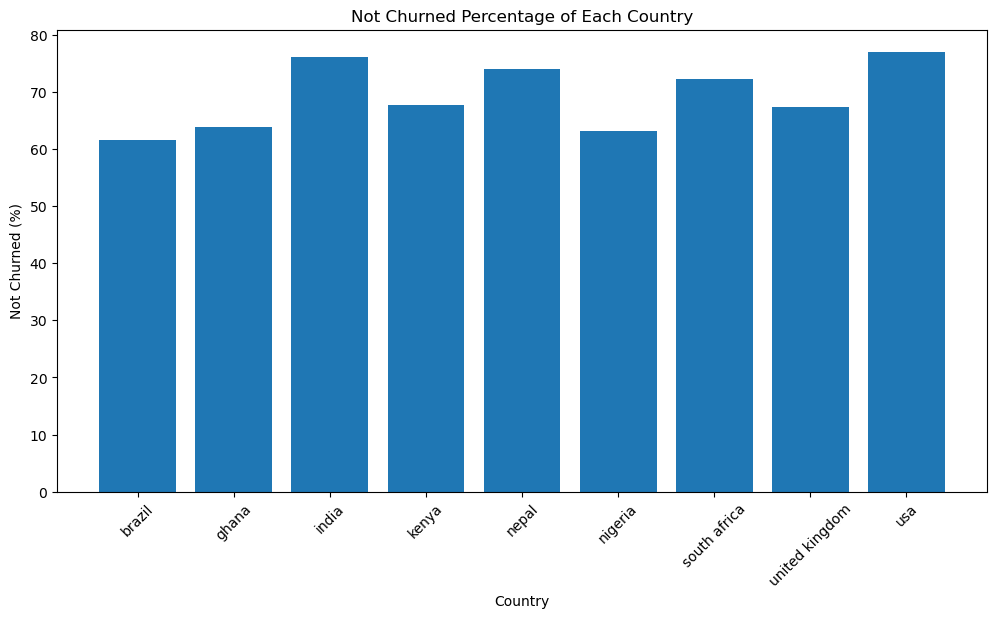

In [135]:
plt.figure(figsize=(12, 6))
plt.bar(not_churn_percentage.index, not_churn_percentage.values)
plt.title("Not Churned Percentage of Each Country")
plt.xlabel("Country")
plt.ylabel("Not Churned (%)")
plt.xticks(rotation=45)
plt.show()

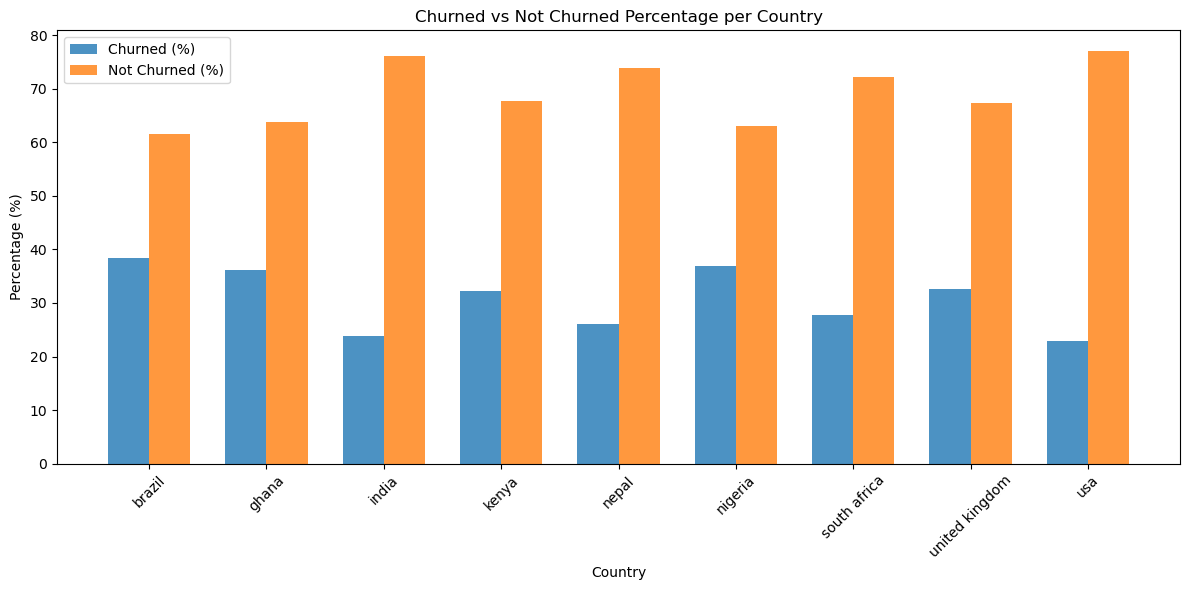

In [136]:
# Total churned and not churned per country
country_churn = df[df['churned'] == 1].groupby('country').size()
country_not_churn = df[df['churned'] == 0].groupby('country').size()

# List of all countries
countries = sorted(df['country'].unique())

# Reindex to avoid missing values
country_churn = country_churn.reindex(countries, fill_value=0)
country_not_churn = country_not_churn.reindex(countries, fill_value=0)

# Total users per country
total_per_country = country_churn + country_not_churn

# Convert to percentages
churn_pct = (country_churn / total_per_country) * 100
not_churn_pct = (country_not_churn / total_per_country) * 100

# X-axis positions
x = np.arange(len(countries))
width = 0.35

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, churn_pct, width, label='Churned (%)', alpha=0.8)
plt.bar(x + width/2, not_churn_pct, width, label='Not Churned (%)', alpha=0.8)

plt.title("Churned vs Not Churned Percentage per Country")
plt.xlabel("Country")
plt.ylabel("Percentage (%)")
plt.xticks(x, countries, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [137]:
nep_data = df[df['country']=='nepal']
nep_data 

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
0,U1403,nepal,23,Female,Premium,11.5,510,0.05,2.000000,0,7.99,21/03/2024
1,U1165,nepal,63,Male,Student,11.3,526,0.05,3.000000,0,0.00,08/10/2023
18,U1304,nepal,18,Female,Family,9.5,454,0.10,1.000000,0,9.99,10/06/2024
25,U1347,nepal,20,Male,Family,10.5,478,0.20,4.000000,0,12.99,28/09/2022
34,U1452,nepal,63,Male,Family,10.7,528,0.20,4.000000,0,7.99,29/09/2022
68,U1074,nepal,44,Female,Student,7.5,494,0.10,3.000000,0,12.99,28/05/2022
73,U1670,nepal,15,Male,Family,9.9,485,0.25,4.000000,1,5.00,07/02/2023
90,U1313,nepal,33,Female,Family,11.7,469,0.20,3.000000,0,9.99,08/04/2024
95,U1249,nepal,26,Male,Student,12.9,464,0.20,2.000000,0,5.00,31/07/2022
99,U1434,nepal,51,Female,Family,7.5,487,0.30,3.000000,0,9.99,26/11/2022


In [138]:
nep_not_churn = nep_data[nep_data['churned'] == 0]
nep_not_churn.head()

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
0,U1403,nepal,23,Female,Premium,11.5,510,0.05,2.0,0,7.99,21/03/2024
1,U1165,nepal,63,Male,Student,11.3,526,0.05,3.0,0,0.00,08/10/2023
18,U1304,nepal,18,Female,Family,9.5,454,0.10,1.0,0,9.99,10/06/2024
25,U1347,nepal,20,Male,Family,10.5,478,0.20,4.0,0,12.99,28/09/2022
34,U1452,nepal,63,Male,Family,10.7,528,0.20,4.0,0,7.99,29/09/2022


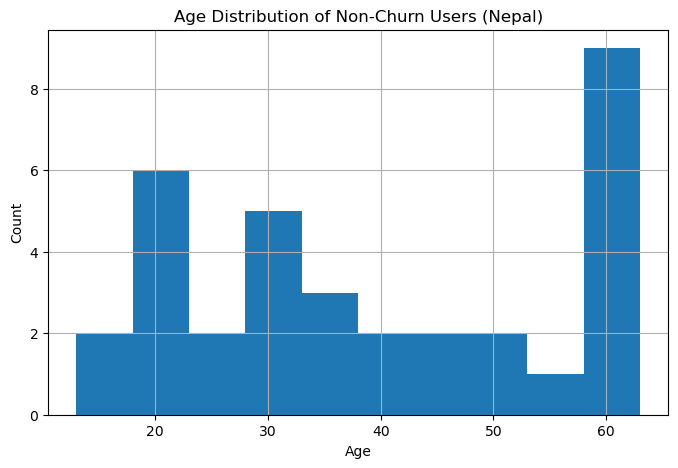

In [139]:
nep_not_churn['age'].hist(bins=10, figsize=(8,5))
plt.title("Age Distribution of Non-Churn Users (Nepal)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

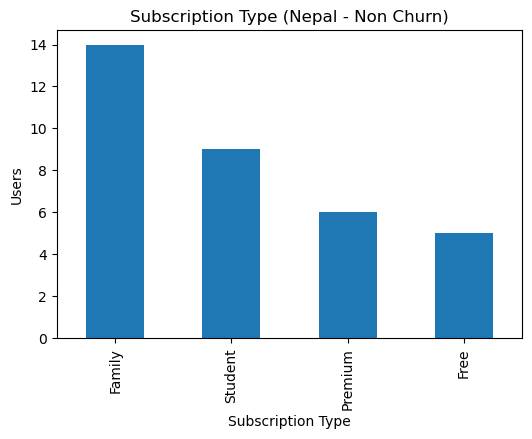

In [140]:
nep_not_churn['subscription_type'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Subscription Type (Nepal - Non Churn)")
plt.xlabel("Subscription Type")
plt.ylabel("Users")
plt.show()

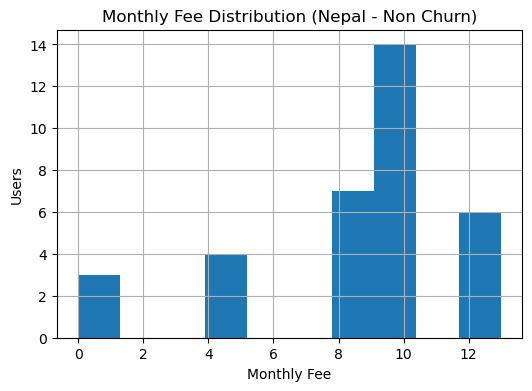

In [141]:
nep_not_churn['monthly_fee'].hist(figsize=(6,4))
plt.title("Monthly Fee Distribution (Nepal - Non Churn)")
plt.xlabel("Monthly Fee")
plt.ylabel("Users")
plt.show()

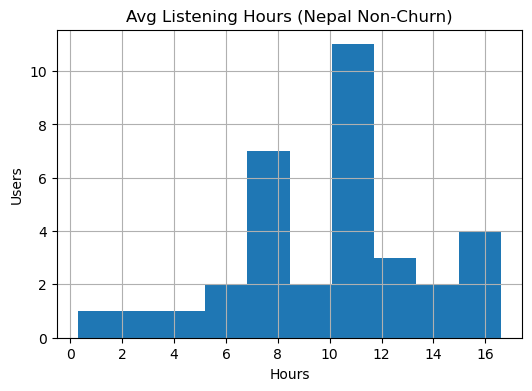

In [142]:
nep_not_churn['avg_listening_hours_per_week'].hist(figsize=(6,4))
plt.title("Avg Listening Hours (Nepal Non-Churn)")
plt.xlabel("Hours")
plt.ylabel("Users")
plt.show()

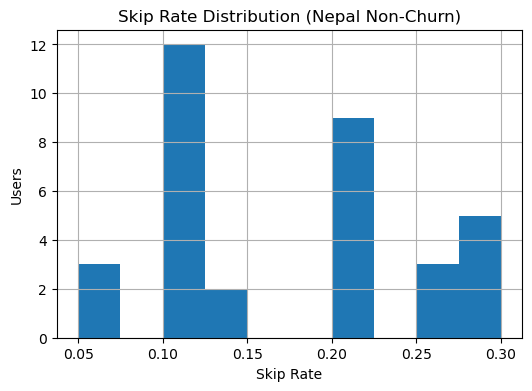

In [143]:
nep_not_churn['skip_rate'].hist(figsize=(6,4))
plt.title("Skip Rate Distribution (Nepal Non-Churn)")
plt.xlabel("Skip Rate")
plt.ylabel("Users")
plt.show()

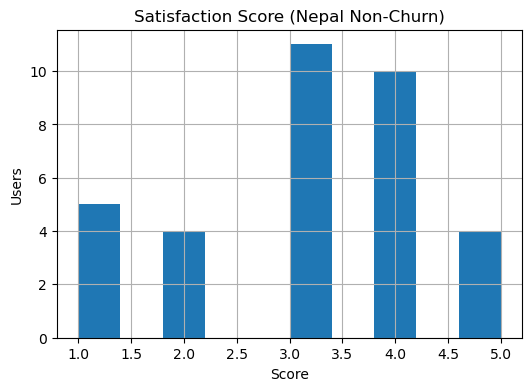

In [144]:
nep_not_churn['satisfaction_score'].hist(figsize=(6,4))
plt.title("Satisfaction Score (Nepal Non-Churn)")
plt.xlabel("Score")
plt.ylabel("Users")
plt.show()

In [145]:
nep_data['join_date']= pd.to_datetime(nep_data['join_date'])
nep_data['join_year'] = nep_data['join_date'].dt.year


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\3972860248.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  nep_data['join_date']= pd.to_datetime(nep_data['join_date'])
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\3972860248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nep_data['join_date']= pd.to_datetime(nep_data['join_date'])
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\3972860248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [146]:
def calculate_months(start_date, end_date):
    rd= relativedelta(end_date, start_date)
    return rd.years * 12 + rd.months

In [147]:
nep_not_churn['join_date'] = pd.to_datetime(nep_not_churn['join_date'])


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\2564484644.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  nep_not_churn['join_date'] = pd.to_datetime(nep_not_churn['join_date'])
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\2564484644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nep_not_churn['join_date'] = pd.to_datetime(nep_not_churn['join_date'])


In [148]:
today = pd.Timestamp.today()
nep_not_churn['months_active'] = (today - nep_not_churn['join_date']) / np.timedelta64(1, 'm')
nep_not_churn['months_active'] = nep_not_churn['months_active'].astype(int)

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\2577766300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nep_not_churn['months_active'] = (today - nep_not_churn['join_date']) / np.timedelta64(1, 'm')
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\2577766300.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nep_not_churn['months_active'] = nep_not_churn['months_active'].astype(int)


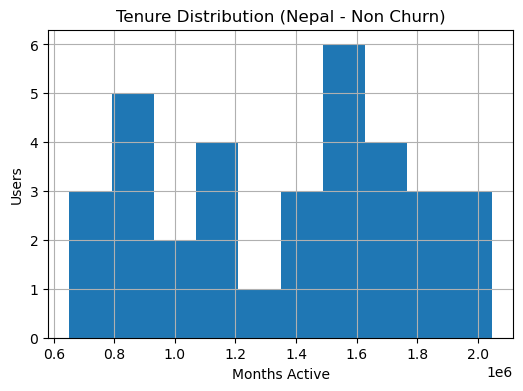

In [149]:
nep_not_churn['months_active'].hist(figsize=(6,4))
plt.title("Tenure Distribution (Nepal - Non Churn)")
plt.xlabel("Months Active")
plt.ylabel("Users")
plt.show()

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\91958943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nep_not_churn['listening_norm'] = (nep_not_churn['avg_listening_hours_per_week'] - nep_not_churn['avg_listening_hours_per_week'].min()) / (nep_not_churn['avg_listening_hours_per_week'].max() - nep_not_churn['avg_listening_hours_per_week'].min())
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\91958943.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nep_not_churn['skip_norm'] = (ne

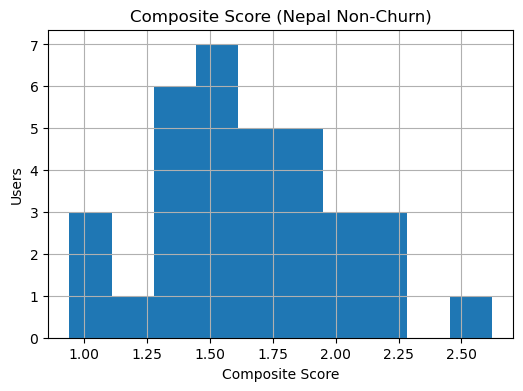

In [150]:
nep_not_churn['listening_norm'] = (nep_not_churn['avg_listening_hours_per_week'] - nep_not_churn['avg_listening_hours_per_week'].min()) / (nep_not_churn['avg_listening_hours_per_week'].max() - nep_not_churn['avg_listening_hours_per_week'].min())
nep_not_churn['skip_norm'] = (nep_not_churn['skip_rate'] - nep_not_churn['skip_rate'].min()) / (nep_not_churn['skip_rate'].max() - nep_not_churn['skip_rate'].min())
nep_not_churn['satisfaction_norm'] = (nep_not_churn['satisfaction_score'] - nep_not_churn['satisfaction_score'].min()) / (nep_not_churn['satisfaction_score'].max() - nep_not_churn['satisfaction_score'].min())

# Create composite score (higher is better)
nep_not_churn['composite_score'] = nep_not_churn['listening_norm'] * 1 + (1 - nep_not_churn['skip_norm']) * 1 + nep_not_churn['satisfaction_norm'] * 1

# Now you can plot
nep_not_churn['composite_score'].hist(figsize=(6,4))
plt.title("Composite Score (Nepal Non-Churn)")
plt.xlabel("Composite Score")
plt.ylabel("Users")
plt.show()


In [165]:
nep_not_churn['tenure_group'] = pd.cut(
    nep_not_churn['months_active'],
    bins=[0, 3, 6, 12, 24, 36, 60],
    labels=['0–3 Mo', '4–6 Mo', '7–12 Mo', '13–24 Mo', '25–36 Mo', '37–60 Mo']
)

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\515812819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nep_not_churn['tenure_group'] = pd.cut(


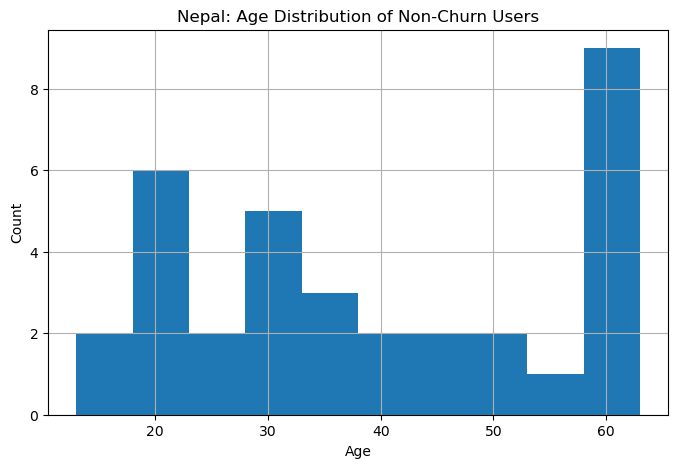

In [152]:
plt.figure(figsize=(8,5))
nep_not_churn['age'].hist(bins=10)
plt.title("Nepal: Age Distribution of Non-Churn Users")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

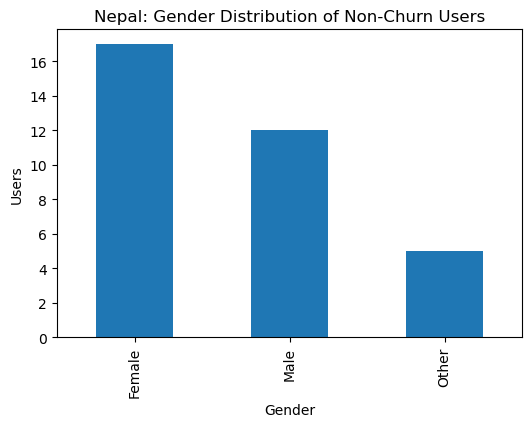

In [153]:
plt.figure(figsize=(6,4))
nep_not_churn['gender'].value_counts().plot(kind='bar')
plt.title("Nepal: Gender Distribution of Non-Churn Users")
plt.xlabel("Gender")
plt.ylabel("Users")
plt.show()

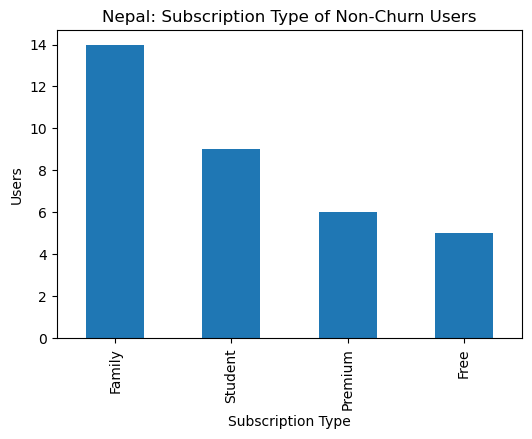

In [154]:
plt.figure(figsize=(6,4))
nep_not_churn['subscription_type'].value_counts().plot(kind='bar')
plt.title("Nepal: Subscription Type of Non-Churn Users")
plt.xlabel("Subscription Type")
plt.ylabel("Users")
plt.show()

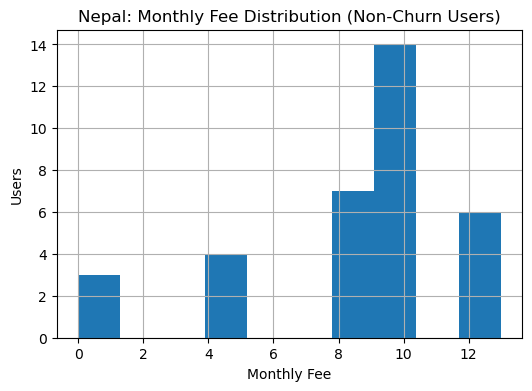

In [155]:
plt.figure(figsize=(6,4))
nep_not_churn['monthly_fee'].hist()
plt.title("Nepal: Monthly Fee Distribution (Non-Churn Users)")
plt.xlabel("Monthly Fee")
plt.ylabel("Users")
plt.show()

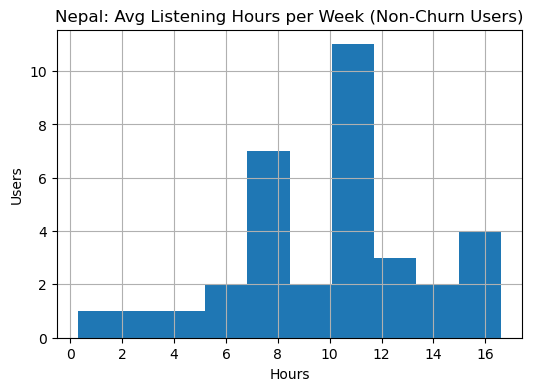

In [156]:
plt.figure(figsize=(6,4))
nep_not_churn['avg_listening_hours_per_week'].hist()
plt.title("Nepal: Avg Listening Hours per Week (Non-Churn Users)")
plt.xlabel("Hours")
plt.ylabel("Users")
plt.show()


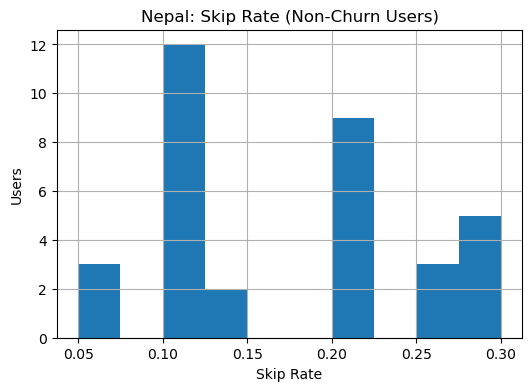

In [157]:
plt.figure(figsize=(6,4))
nep_not_churn['skip_rate'].hist()
plt.title("Nepal: Skip Rate (Non-Churn Users)")
plt.xlabel("Skip Rate")
plt.ylabel("Users")
plt.show()


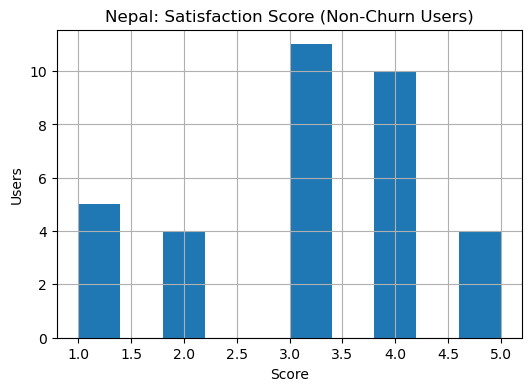

In [158]:
plt.figure(figsize=(6,4))
nep_not_churn['satisfaction_score'].hist()
plt.title("Nepal: Satisfaction Score (Non-Churn Users)")
plt.xlabel("Score")
plt.ylabel("Users")
plt.show()

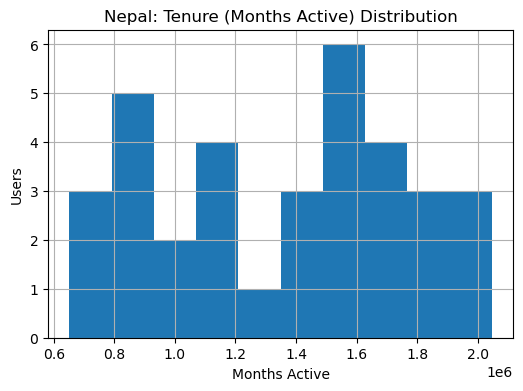

In [159]:
plt.figure(figsize=(6,4))
nep_not_churn['months_active'].hist()
plt.title("Nepal: Tenure (Months Active) Distribution")
plt.xlabel("Months Active")
plt.ylabel("Users")
plt.show()


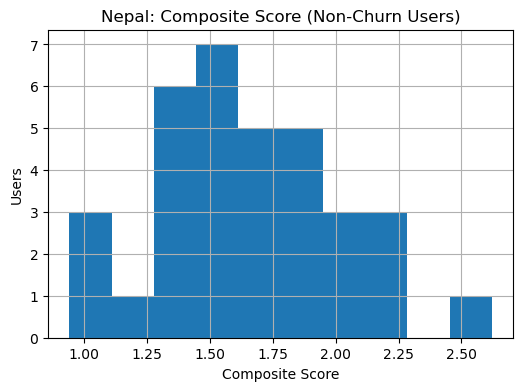

In [160]:
plt.figure(figsize=(6,4))
nep_not_churn['composite_score'].hist()
plt.title("Nepal: Composite Score (Non-Churn Users)")
plt.xlabel("Composite Score")
plt.ylabel("Users")
plt.show()

In [163]:
heatmap_data = nep_not_churn.groupby('tenure_group')['composite_score'].mean()
heatmap_df = heatmap_data.pivot_table(values='composite_score', index='tenure_group')
plt.figure(figsize=(6,6))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu")
plt.title("Nepal: Composite Score by Tenure Group")
plt.ylabel("Tenure Group")
plt.show()

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_15592\2087984135.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = nep_not_churn.groupby('tenure_group')['composite_score'].mean()


AttributeError: 'Series' object has no attribute 'pivot_table'

In [166]:
nep_not_churn

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,months_active,listening_norm,skip_norm,satisfaction_norm,composite_score,tenure_group
0,U1403,nepal,23,Female,Premium,11.5,510,0.05,2.000000,0,7.99,2024-03-21,885560,0.687117,0.0,0.250000,1.937117,NaN
1,U1165,nepal,63,Male,Student,11.3,526,0.05,3.000000,0,0.00,2023-10-08,1123160,0.674847,0.0,0.500000,2.174847,NaN
18,U1304,nepal,18,Female,Family,9.5,454,0.10,1.000000,0,9.99,2024-06-10,768920,0.564417,0.2,0.000000,1.364417,NaN
25,U1347,nepal,20,Male,Family,10.5,478,0.20,4.000000,0,12.99,2022-09-28,1663160,0.625767,0.6,0.750000,1.775767,NaN
34,U1452,nepal,63,Male,Family,10.7,528,0.20,4.000000,0,7.99,2022-09-29,1661720,0.638037,0.6,0.750000,1.788037,NaN
68,U1074,nepal,44,Female,Student,7.5,494,0.10,3.000000,0,12.99,2022-05-28,1840280,0.441718,0.2,0.500000,1.741718,NaN
90,U1313,nepal,33,Female,Family,11.7,469,0.20,3.000000,0,9.99,2024-04-08,859640,0.699387,0.6,0.500000,1.599387,NaN
95,U1249,nepal,26,Male,Student,12.9,464,0.20,2.000000,0,5.00,2022-07-31,1748120,0.773006,0.6,0.250000,1.423006,NaN
99,U1434,nepal,51,Female,Family,7.5,487,0.30,3.000000,0,9.99,2022-11-26,1578200,0.441718,1.0,0.500000,0.941718,NaN
123,U1513,nepal,32,Male,Premium,13.1,561,0.30,5.000000,0,9.99,2023-02-23,1450040,0.785276,1.0,1.000000,1.785276,NaN
